# California Housing: Logistic Regression and Neural Networks for Binary Classification

This notebook introduces **binary classification** using the California Housing dataset.
We convert the original regression target into a binary label:

- `1` if `MedHouseVal > 2.5`
- `0` otherwise

The notebook then covers:

1. Logistic regression for binary classification
2. Model evaluation with:
   - Accuracy
   - Confusion matrix
   - ROC curve and ROC AUC
   - Precision-recall curve and Average Precision
3. A neural network classifier implemented in **PyTorch**
4. A more detailed training procedure for the neural network
5. A small patch for running the notebook in **Google Colab**


## 1. Google Colab Patch

If you run this notebook in Google Colab, the next cell installs any missing packages.
On a local machine, it should simply do nothing if everything is already installed.

In [1]:
import sys
import subprocess

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'scikit-learn', 'matplotlib', 'pandas', 'torch'])
    print('Installed/verified packages for Google Colab.')
else:
    print('Not running in Google Colab. Skipping install patch.')


Not running in Google Colab. Skipping install patch.


## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


## 3. Load the Data and Build a Binary Target

In [3]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

threshold = 2.5
df['HighValue'] = (df['MedHouseVal'] > threshold).astype(int)

print('Feature names:', housing.feature_names)
print('Original target:', housing.target_names)
print('Binary target threshold:', threshold)
print('Dataset shape:', df.shape)
df.head()


Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Original target: ['MedHouseVal']
Binary target threshold: 2.5
Dataset shape: (20640, 10)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,HighValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,1
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,1
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,1
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,1
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,1


In [4]:
target_counts = df['HighValue'].value_counts().sort_index()
target_share = df['HighValue'].value_counts(normalize=True).sort_index()

summary = pd.DataFrame({
    'count': target_counts,
    'share': target_share.round(4)
})
summary.index = ['MedHouseVal <= 2.5', 'MedHouseVal > 2.5']
summary


,count,share
MedHouseVal <= 2.5,14858,0.7199
MedHouseVal > 2.5,5782,0.2801


## 4. Train/Test Split

In [5]:
X = df.drop(columns=['MedHouseVal', 'HighValue'])
y = df['HighValue']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Train positive rate:', round(y_train.mean(), 4))
print('Test positive rate:', round(y_test.mean(), 4))


X_train shape: (16512, 8)
X_test shape: (4128, 8)
Train positive rate: 0.2802
Test positive rate: 0.28


## 5. Logistic Regression for Binary Classification

Logistic regression is a simple but strong baseline for binary classification.
We standardize the input features and fit a logistic regression model.

In [6]:
log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print('Logistic regression trained successfully.')


Logistic regression trained successfully.


## 6. Logistic Regression Evaluation

We evaluate the classifier from several angles:

- **Accuracy**: overall fraction of correct predictions
- **Confusion matrix**: true/false positives and negatives
- **ROC curve**: tradeoff between true positive rate and false positive rate
- **Precision-recall curve**: tradeoff between precision and recall, especially useful when classes are imbalanced


In [7]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
avg_precision_lr = average_precision_score(y_test, y_proba_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(f'Accuracy: {accuracy_lr:.4f}')
print(f'ROC AUC: {roc_auc_lr:.4f}')
print(f'Average Precision: {avg_precision_lr:.4f}')
print('\nClassification report:\n')
print(classification_report(y_test, y_pred_lr, digits=4))


Accuracy: 0.8525
ROC AUC: 0.9195
Average Precision: 0.8299

Classification report:

              precision    recall  f1-score   support

           0     0.8747    0.9280    0.9006      2972
           1     0.7805    0.6583    0.7142      1156

    accuracy                         0.8525      4128
   macro avg     0.8276    0.7931    0.8074      4128
weighted avg     0.8483    0.8525    0.8484      4128



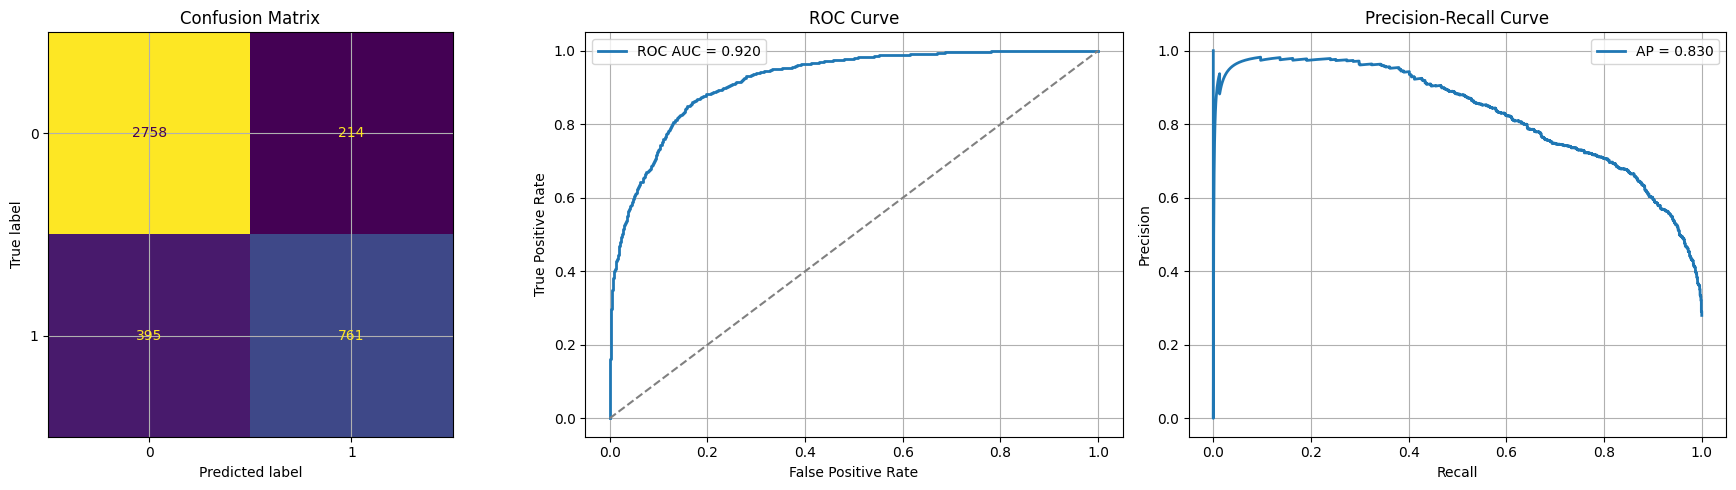

In [8]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_proba_lr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(cm_lr).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

axes[1].plot(fpr_lr, tpr_lr, linewidth=2, label=f'ROC AUC = {roc_auc_lr:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

axes[2].plot(recall_lr, precision_lr, linewidth=2, label=f'AP = {avg_precision_lr:.3f}')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.show()


In [9]:
feature_names = X_train.columns
coef_values = log_reg.named_steps['model'].coef_[0]

coef_table = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef_values,
    'abs_coefficient': np.abs(coef_values)
}).sort_values('abs_coefficient', ascending=False)

coef_table[['feature', 'coefficient']]


,feature,coefficient
5,AveOccup,-4.746997
6,Latitude,-3.754372
7,Longitude,-3.534070
0,MedInc,2.340487
3,AveBedrms,0.803714
2,AveRooms,-0.667435
1,HouseAge,0.431288
4,Population,0.086414


## 7. Neural Network Classifier with PyTorch

Next we build a small neural network for the same binary classification task.
Compared with logistic regression, a neural network can model **nonlinear relationships**.

We will follow a more detailed training procedure:

1. Standardize the features
2. Convert the data to PyTorch tensors
3. Create `DataLoader` objects for mini-batch training
4. Define the model, loss function, and optimizer
5. Train for multiple epochs while tracking loss and accuracy
6. Evaluate the final model on the test set


In [10]:
scaler_nn = StandardScaler()
X_train_scaled = scaler_nn.fit_transform(X_train)
X_test_scaled = scaler_nn.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cpu


In [11]:
class BinaryClassifierNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)


model_nn = BinaryClassifierNN(input_dim=X_train.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_nn.parameters(), lr=1e-3)

model_nn


BinaryClassifierNN(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)

## 8. Detailed Training Procedure

In each epoch we:

- move a mini-batch to the selected device
- compute the logits with the model
- calculate binary cross-entropy loss
- backpropagate the gradients
- update the weights with Adam
- track training and validation metrics over time


In [12]:
def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            batch_size = xb.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (preds == yb).sum().item()
            total_samples += batch_size

            all_probs.append(probs.cpu())
            all_targets.append(yb.cpu())

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    all_probs = torch.cat(all_probs).numpy().ravel()
    all_targets = torch.cat(all_targets).numpy().ravel()

    return avg_loss, avg_acc, all_probs, all_targets


In [13]:
num_epochs = 25

history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': [],
}

for epoch in range(1, num_epochs + 1):
    model_nn.train()
    running_loss = 0.0
    running_correct = 0
    running_samples = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model_nn(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        batch_size = xb.size(0)

        running_loss += loss.item() * batch_size
        running_correct += (preds == yb).sum().item()
        running_samples += batch_size

    train_loss = running_loss / running_samples
    train_acc = running_correct / running_samples
    test_loss, test_acc, _, _ = evaluate_model(model_nn, test_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(
        f'Epoch {epoch:02d}/{num_epochs} | '
        f'train_loss={train_loss:.4f} | '
        f'train_acc={train_acc:.4f} | '
        f'test_loss={test_loss:.4f} | '
        f'test_acc={test_acc:.4f}'
    )


Epoch 01/25 | train_loss=0.5945 | train_acc=0.7272 | test_loss=0.5267 | test_acc=0.7544
Epoch 02/25 | train_loss=0.4553 | train_acc=0.8074 | test_loss=0.4065 | test_acc=0.8282
Epoch 03/25 | train_loss=0.3846 | train_acc=0.8402 | test_loss=0.3706 | test_acc=0.8358
Epoch 04/25 | train_loss=0.3612 | train_acc=0.8470 | test_loss=0.3520 | test_acc=0.8406
Epoch 05/25 | train_loss=0.3453 | train_acc=0.8520 | test_loss=0.3369 | test_acc=0.8438
Epoch 06/25 | train_loss=0.3325 | train_acc=0.8572 | test_loss=0.3266 | test_acc=0.8491
Epoch 07/25 | train_loss=0.3229 | train_acc=0.8624 | test_loss=0.3164 | test_acc=0.8551
Epoch 08/25 | train_loss=0.3168 | train_acc=0.8641 | test_loss=0.3110 | test_acc=0.8544
Epoch 09/25 | train_loss=0.3116 | train_acc=0.8654 | test_loss=0.3058 | test_acc=0.8585
Epoch 10/25 | train_loss=0.3078 | train_acc=0.8682 | test_loss=0.3013 | test_acc=0.8609
Epoch 11/25 | train_loss=0.3042 | train_acc=0.8696 | test_loss=0.2973 | test_acc=0.8643
Epoch 12/25 | train_loss=0.3008 

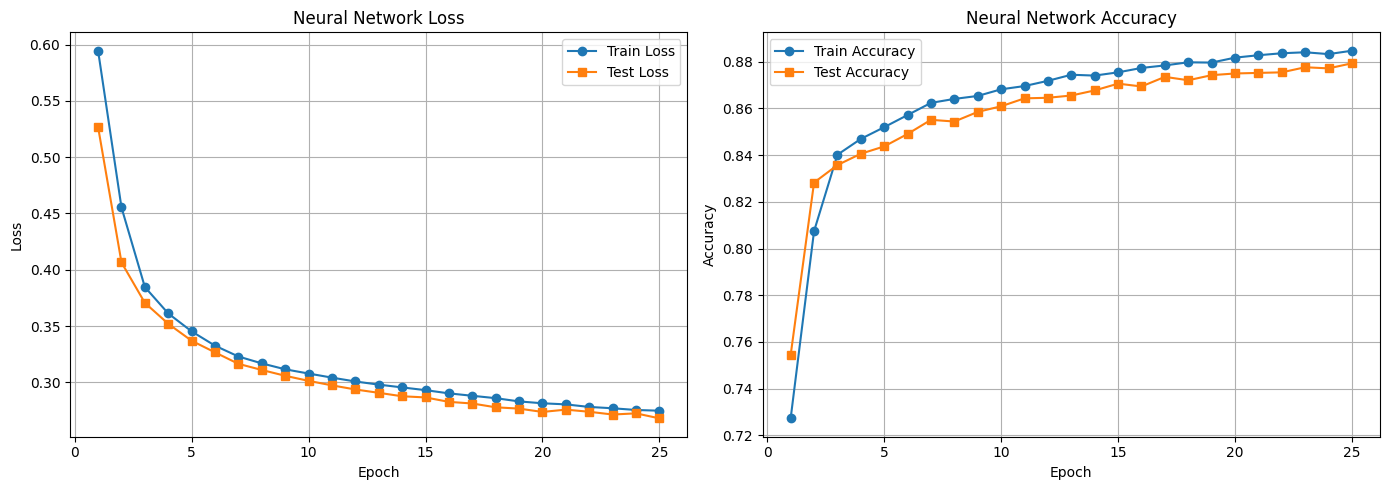

In [14]:
epochs = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history['train_loss'], marker='o', label='Train Loss')
axes[0].plot(epochs, history['test_loss'], marker='s', label='Test Loss')
axes[0].set_title('Neural Network Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs, history['train_acc'], marker='o', label='Train Accuracy')
axes[1].plot(epochs, history['test_acc'], marker='s', label='Test Accuracy')
axes[1].set_title('Neural Network Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Neural Network Evaluation

In [15]:
test_loss_nn, test_acc_nn, y_proba_nn, y_true_nn = evaluate_model(model_nn, test_loader, criterion, device)
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

roc_auc_nn = roc_auc_score(y_true_nn, y_proba_nn)
avg_precision_nn = average_precision_score(y_true_nn, y_proba_nn)
cm_nn = confusion_matrix(y_true_nn, y_pred_nn)

print(f'Test loss: {test_loss_nn:.4f}')
print(f'Test accuracy: {test_acc_nn:.4f}')
print(f'ROC AUC: {roc_auc_nn:.4f}')
print(f'Average Precision: {avg_precision_nn:.4f}')
print('\nClassification report:\n')
print(classification_report(y_true_nn, y_pred_nn, digits=4))


Test loss: 0.2680
Test accuracy: 0.8794
ROC AUC: 0.9438
Average Precision: 0.8797

Classification report:

              precision    recall  f1-score   support

         0.0     0.9072    0.9273    0.9171      2972
         1.0     0.8018    0.7561    0.7783      1156

    accuracy                         0.8794      4128
   macro avg     0.8545    0.8417    0.8477      4128
weighted avg     0.8777    0.8794    0.8783      4128



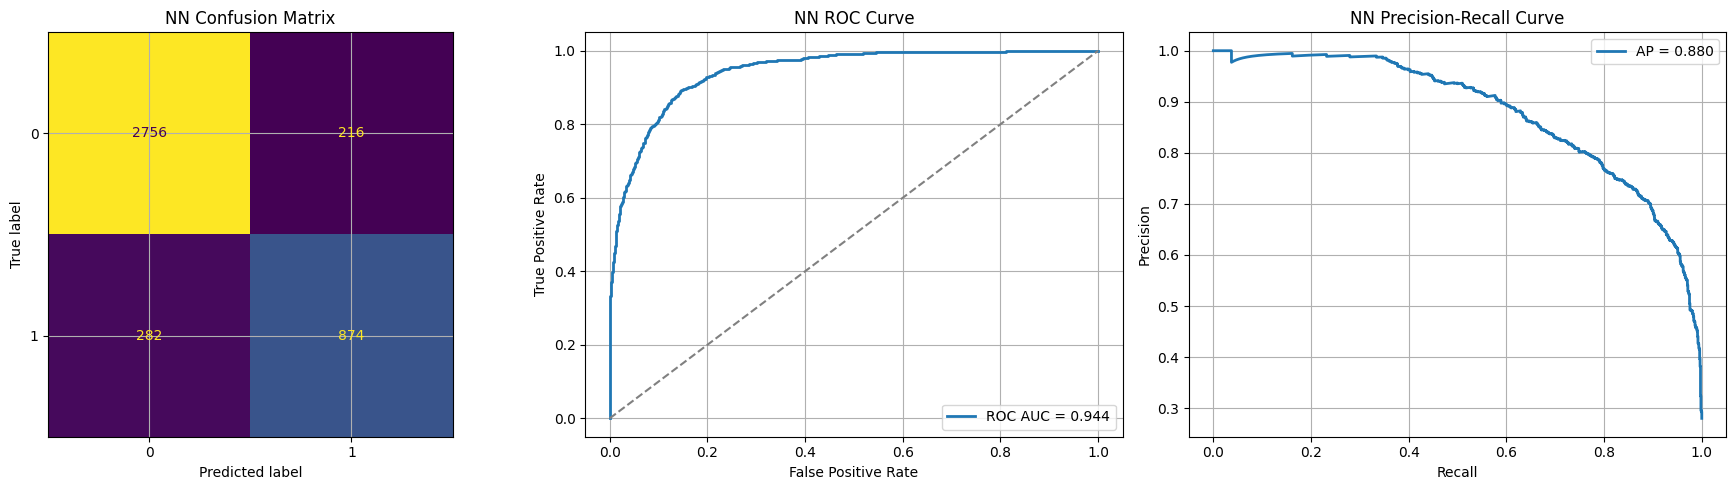

In [16]:
fpr_nn, tpr_nn, _ = roc_curve(y_true_nn, y_proba_nn)
precision_nn, recall_nn, _ = precision_recall_curve(y_true_nn, y_proba_nn)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(cm_nn).plot(ax=axes[0], colorbar=False)
axes[0].set_title('NN Confusion Matrix')

axes[1].plot(fpr_nn, tpr_nn, linewidth=2, label=f'ROC AUC = {roc_auc_nn:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('NN ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

axes[2].plot(recall_nn, precision_nn, linewidth=2, label=f'AP = {avg_precision_nn:.3f}')
axes[2].set_title('NN Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.show()


## 10. Compare Logistic Regression and Neural Network

In [17]:
comparison = pd.DataFrame([
    {
        'model': 'Logistic Regression',
        'accuracy': accuracy_lr,
        'roc_auc': roc_auc_lr,
        'avg_precision': avg_precision_lr,
    },
    {
        'model': 'Neural Network',
        'accuracy': test_acc_nn,
        'roc_auc': roc_auc_nn,
        'avg_precision': avg_precision_nn,
    },
])

comparison.round(4)


,model,accuracy,roc_auc,avg_precision
0,Logistic Regression,0.8525,0.9195,0.8299
1,Neural Network,0.8794,0.9438,0.8797


## 11. Summary

- Logistic regression is a strong and interpretable baseline for binary classification.
- Accuracy alone is not enough; ROC, precision-recall, and the confusion matrix reveal more about performance.
- A neural network can capture nonlinear patterns, but it requires a fuller training pipeline.
- PyTorch gives flexible control over the model, loss, optimizer, and training loop.
